<a href="https://colab.research.google.com/github/luaxavierr/Banco-de-Dados/blob/main/ML5_DecisionTrees_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="Universidade Presbiteriana Mackenzie">
</head>

<img src="http://meusite.mackenzie.br/rogerio/mackenzie_logo/UPM.2_horizontal_vermelho.jpg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->

# **5. Árvores de Decisão e Seleção de Atributos**

---



Após fazer os exercícios deste laboratório responda ao **questionário correspondente da aula no Moodle**.



# Caso: **Propensão de Compra de Clientes por Telemarketing**

https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

Os dados acima estão relacionados com campanhas de marketing direto de uma instituição bancária portuguesa. As campanhas de marketing foram baseadas em telefonemas. Freqüentemente, era necessário mais de um contato para o mesmo cliente, para acessar se o produto (depósito bancário) seria ('yes') ou não ('no') assinado.

Os dados estão na URL: http://meusite.mackenzie.br/rogerio/TIC/bank-full.csv




# Exercício. Acesse e Explore os dados

Inspecione os dados. Qual o atributo classe e quantos registros de cada classe? Existem valores nulos (ausentes) a serem tratados?


In [1]:
# # ==============================================================================
# PROJETO: PROPENSÃO DE COMPRA DE CLIENTES POR TELEMARKETING
# EXERCÍCIO: ACESSE E EXPLORE OS DADOS
# ==============================================================================

# 1. Carregar o dataset. O arquivo CSV está delimitado por ponto e vírgula (sep = ";").
# IMPORTANTE: Garanta que o arquivo 'bank-full.csv' foi ANEXADO (uploaded) à sua sessão do Colab.
import pandas as pd

try:
    dados_banco = pd.read_csv("bank-full.csv", sep = ";")

    # ------------------------------------------------------------------------------
    # INSPEÇÃO 1: ESTRUTURA DOS DADOS (Para inspeção geral e tipos de atributos)
    # Mostra a quantidade de registros, colunas e tipos de dados.
    # ------------------------------------------------------------------------------
    print("### ESTRUTURA DOS DADOS (info) ###")
    dados_banco.info()

    # ------------------------------------------------------------------------------
    # INSPEÇÃO 2: ATRIBUTO CLASSE E CONTAGEM (Para identificar desbalanceamento)
    # O atributo 'y' é a classe (target): 'yes' ou 'no'.
    # ------------------------------------------------------------------------------
    print("\n### CONTAGEM DE REGISTROS POR CLASSE ('y') ###")
    contagem_classe = dados_banco['y'].value_counts()
    print(contagem_classe)

    # Exibir o percentual (opcional, mas recomendado)
    print("\n### PERCENTUAL DE CADA CLASSE ###")
    print(dados_banco['y'].value_counts(normalize=True) * 100)

    # ------------------------------------------------------------------------------
    # INSPEÇÃO 3: VALORES NULOS (NA) EXPLÍCITOS
    # ------------------------------------------------------------------------------
    print("\n### VERIFICAÇÃO DE VALORES NULOS (NA) POR ATRIBUTO ###")
    print(dados_banco.isnull().sum())

    # ------------------------------------------------------------------------------
    # INSPEÇÃO 4 (BÔNUS): Resumo para identificar valores 'unknown'
    # O describe(include='all') revela a presença de 'unknown' em atributos categóricos.
    # ------------------------------------------------------------------------------
    print("\n### RESUMO DOS DADOS (Para identificar 'unknown' ou outros problemas) ###")
    print(dados_banco.describe(include='all'))

except FileNotFoundError:
    print("Erro: O arquivo 'bank-full.csv' não foi encontrado. Por favor, anexe o arquivo à sua sessão do Colab.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")



### ESTRUTURA DOS DADOS (info) ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 1 columns):
 #   Column                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                --------------  ----- 
 0   age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y  45211 non-null  object
dtypes: object(1)
memory usage: 353.3+ KB

### CONTAGEM DE REGISTROS POR CLASSE ('y') ###
Ocorreu um erro: 'y'


# Exercício. Defina as entradas `X` e saída `y` modelo

Lembre-se, em um modelo de classificação $X$ são as variáveis preditoras (*independentes*) e $y$ sua variável objetivo (*dependente*). Nesse momento você não precisa se preocupar com conversão de valores, como por exemplo, *hot-encode*. Apenas verifique e associe os dados correspondentes às variáveis `X` e `y`.

In [2]:
#import pandas as pd

# GARANTINDO O CARREGAMENTO DOS DADOS COM O SEPARADOR CORRETO (Vírgula ',')
try:
    # A linha foi corrigida de sep = ";" para sep = ","
    dados_banco = pd.read_csv("bank-full.csv", sep = ",")

    # ==============================================================================
    # EXERCÍCIO: DEFINIÇÃO DAS VARIÁVEIS DE ENTRADA (X) E SAÍDA (y)
    # ==============================================================================

    # 1. Definir a Variável Saída (y) - Variável Objetivo (Dependente)
    y = dados_banco['y'] # Agora a coluna 'y' existe!

    # 2. Definir as Variáveis de Entrada (X) - Variáveis Preditoras (Independentes)
    X = dados_banco.drop('y', axis=1)

    # 3. Verificação
    print("### SUCESSO NA SEPARAÇÃO DE X e y ###")
    print(f"Formato da Matriz de Entradas (X): {X.shape}")
    print(f"Número de Variáveis Preditoras em X: {len(X.columns)}")
    print(f"Formato do Vetor Saída (y): {y.shape}")
    print("-" * 35)
    print("Primeiros atributos de X (Entradas):")
    print(X.head(2))

except FileNotFoundError:
    print("Erro: O arquivo 'bank-full.csv' não foi encontrado. Por favor, anexe o arquivo à sua sessão do Colab.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")


### SUCESSO NA SEPARAÇÃO DE X e y ###
Formato da Matriz de Entradas (X): (45211, 16)
Número de Variáveis Preditoras em X: 16
Formato do Vetor Saída (y): (45211,)
-----------------------------------
Primeiros atributos de X (Entradas):
   age         job  marital  education default  balance housing loan  contact  \
0   58  management  married   tertiary      no     2143     yes   no  unknown   
1   44  technician   single  secondary      no       29     yes   no  unknown   

   day month  duration  campaign  pdays  previous poutcome  
0    5   may       261         1     -1         0  unknown  
1    5   may       151         1     -1         0  unknown  


# Preparação dos Dados

A **Preparação dos Dados**, como você já viu, consiste em transformações  que são necessárias ou úteis para preparar os dados para uso dos modelos. Encontram-se entre essas transformações:

1. Tratamento de valores faltantes
2. Normalizações
3. Codificação de Valores categóricos para numéricos (*encode*)
4. Codificação de Valores numéricos para classes de valores (discretização ou *binning*)
5. etc.

Vamos fazer aqui duas operações sobre os dados:

1. **Label encode**. Embora Árvores de Decisão possam empregar atributos categóricos, o `scikit-learn` requer que esses atributos sejam `label_encode`. É um requerimento da tecnologia, não do modelo.

1. **Normalização**. Árvores de Decisão também podem ser sensíveis a variação de escala e mas vamos reescalar aqui também os dados.

A primeira transformação é meramente técnica e faremos para você. Mas observe o código, ele pode ser útil a você nos casos em quem muitos atributos precisam ser codificados, com Hot ou Label encode.

# Exercício. **Label Encode (RESOLVIDO)**

Podemos fazer isso de diversas formas, mas o `scikit-learn` traz funções para isso.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_categorical = X.select_dtypes(exclude='number')
#  label encoding to all the columns

display('Label Encode attributes: ', df_categorical)

display('education, valores e suas quantidades antes: ', X.education.value_counts())

label_encoders = {}
for col in df_categorical:
  le = LabelEncoder()
  le.fit(X[col])
  X[col] = le.transform(X[col])
  label_encoders[col] = le # salva para empregar para novas instâncias

display('education, valores e suas quantidades depois: ', X.education.value_counts())

display('Label Encode attributes depois: ', X)

'Label Encode attributes: '

,job,marital,education,default,housing,loan,contact,month,poutcome
0,management,married,tertiary,no,yes,no,unknown,may,unknown
1,technician,single,secondary,no,yes,no,unknown,may,unknown
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown
4,unknown,single,unknown,no,no,no,unknown,may,unknown
...,...,...,...,...,...,...,...,...,...
45206,technician,married,tertiary,no,no,no,cellular,nov,unknown
45207,retired,divorced,primary,no,no,no,cellular,nov,unknown
45208,retired,married,secondary,no,no,no,cellular,nov,success
45209,blue-collar,married,secondary,no,no,no,telephone,nov,unknown


'education, valores e suas quantidades antes: '

secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: education, dtype: int64

'education, valores e suas quantidades depois: '

1    23202
2    13301
0     6851
3     1857
Name: education, dtype: int64

'Label Encode attributes depois: '

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,9,1,2,0,825,0,0,0,17,9,977,3,-1,0,3
45207,71,5,0,0,0,1729,0,0,0,17,9,456,2,-1,0,3
45208,72,5,1,1,0,5715,0,0,0,17,9,1127,5,184,3,2
45209,57,1,1,1,0,668,0,0,1,17,9,508,4,-1,0,3


# Exercício. Explore as técnicas de *Scale*

Verifique quais  métodos abaixo correspondem aos esquemas de normalização:

$$ X_s = (X - X_{min}) / (X_{max} - X_{min}) $$

e a:

$$ X_s = (X - X_{mean}) / X_{std} $$

Esta última corresponde a ter dados com média 0 e desvio padrão 1. Você pode buscar empregar um conjunto qualquer de dados para testar os métodos.

In [ ]:
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MaxAbsScaler

In [3]:
# import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Dados de Exemplo (para demonstração)
# Um conjunto simples para facilitar a visualização da transformação
data = pd.DataFrame({'Valor': [10, 20, 30, 40, 100]})
print("1. Dados Originais:\n", data)

# ==============================================================================
# TESTE 1: StandardScaler (Z-Score)
# Resultado esperado: Média = 0, Desvio Padrão = 1
# ==============================================================================
standard_scaler = StandardScaler()
data['Z_Score_Scaled'] = standard_scaler.fit_transform(data[['Valor']])

print("\n2. Padronização Z-Score (StandardScaler):")
print(data[['Z_Score_Scaled']].describe())
# Observe que a média (mean) é quase zero e o DP (std) é 1.0.

# ==============================================================================
# TESTE 2: MinMaxScaler
# Resultado esperado: Mínimo = 0, Máximo = 1
# ==============================================================================
min_max_scaler = MinMaxScaler()
data['MinMax_Scaled'] = min_max_scaler.fit_transform(data[['Valor']])

print("\n3. Normalização Min-Max (MinMaxScaler):")
print(data[['MinMax_Scaled']].describe().loc[['min', 'max']])
# Observe que o mínimo é 0 e o máximo é 1.

print("\nDataFrame Completo após os testes:")
print(data)

1. Dados Originais:
    Valor
0     10
1     20
2     30
3     40
4    100

2. Padronização Z-Score (StandardScaler):
       Z_Score_Scaled
count        5.000000
mean         0.000000
std          1.118034
min         -0.948683
25%         -0.632456
50%         -0.316228
75%          0.000000
max          1.897367

3. Normalização Min-Max (MinMaxScaler):
     MinMax_Scaled
min            0.0
max            1.0

DataFrame Completo após os testes:
   Valor  Z_Score_Scaled  MinMax_Scaled
0     10       -0.948683       0.000000
1     20       -0.632456       0.111111
2     30       -0.316228       0.222222
3     40        0.000000       0.333333
4    100        1.897367       1.000000


# Exercício. Normalizando os Dados

Aplique a normalização que leva os valores à média 0 e desvio padrão 1.

In [4]:
# import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ==============================================================================
# ETAPA 1: CARREGAMENTO E PREPARAÇÃO INICIAL DE X e y
# (Resolvendo a dependência de dados e Label Encoding categórico)
# ==============================================================================

try:
    # 1. Carregamento dos dados (com separador correto ',')
    dados_banco = pd.read_csv("bank-full.csv", sep = ",")

    # 2. Definir a Variável Saída (y) e Entrada (X)
    y = dados_banco['y']
    X = dados_banco.drop('y', axis=1)

    # 3. Label Encoding para colunas categóricas em X (RESOLVIDO)
    df_categorical = X.select_dtypes(include='object').columns

    for col in df_categorical:
        le = LabelEncoder()
        # O fit e transform aplicam a codificação para números
        X[col] = le.fit_transform(X[col])

    # NOTA: Agora X contém apenas números.

except Exception as e:
    print(f"Erro Crítico de Preparação de Dados: {e}")
    exit()

# ==============================================================================
# EXERCÍCIO ATUAL: NORMALIZAÇÃO DOS DADOS (Z-SCORE)
# ==============================================================================

print("Iniciando Padronização Z-Score...")

# 1. Identificar TODAS as colunas numéricas (incluindo as recém-codificadas)
# Como o LabelEncoder transforma as colunas em 'int64' ou 'float64',
# aplicamos o StandardScaler a todas as colunas de X.
colunas_para_normalizar = X.columns

# 2. Inicializar o Padronizador (StandardScaler)
# O StandardScaler aplica a normalização Z-Score (média=0, desvio padrão=1)
scaler = StandardScaler()

# 3. Aplicar a Padronização (StandardScaler) a todas as colunas em X
# fit_transform calcula média/DP (fit) e aplica a transformação (transform)
X_normalizado = scaler.fit_transform(X)

# 4. Converter o array numpy resultante de volta para um DataFrame do Pandas
X = pd.DataFrame(
    X_normalizado,
    columns=colunas_para_normalizar,
    index=X.index
)

# 5. Verificação da Normalização
print("\n### SUCESSO NA NORMALIZAÇÃO Z-SCORE ###")
print("Estatísticas das Variáveis (Média deve ser ≈ 0, Desvio Padrão ≈ 1):")
# Mostra as estatísticas das primeiras colunas para confirmação
print(X.describe().loc[['mean', 'std']].iloc[:, :5]) # Mostra as 5 primeiras colunas


Iniciando Padronização Z-Score...

### SUCESSO NA NORMALIZAÇÃO Z-SCORE ###
Estatísticas das Variáveis (Média deve ser ≈ 0, Desvio Padrão ≈ 1):
               age           job       marital     education       default
mean  2.112250e-16 -5.532084e-17  8.801042e-17 -9.052501e-17 -3.771875e-17
std   1.000011e+00  1.000011e+00  1.000011e+00  1.000011e+00  1.000011e+00


# Exercício. Conjunto de Treinamento e Teste

Empregue a função `train_test_split` e separe 0.3 dos dados para teste. Empregue o `random_state=123` para garantir a reprodutibilidade dos resultados e empregue o parâmetro `stratify` para garantir a mesma distribuição das classes nos conjuntos de treinamento e teste.

In [5]:
# import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ==============================================================================
# ETAPA 1: PREPARAÇÃO COMPLETA DE X E Y (LABEL ENCODING E NORMALIZAÇÃO)
# ==============================================================================

print("Iniciando Preparação de Dados (Carregamento, Encoding, Normalização)...")

try:
    # 1. Carregamento dos dados
    dados_banco = pd.read_csv("bank-full.csv", sep = ",")
    y = dados_banco['y']
    X = dados_banco.drop('y', axis=1)

    # 2. Label Encoding para colunas categóricas em X (RESOLVIDO)
    df_categorical = X.select_dtypes(include='object').columns
    for col in df_categorical:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

    # 3. Normalização Z-Score (StandardScaler) em todas as colunas de X (RESOLVIDO)
    scaler = StandardScaler()
    X_normalizado = scaler.fit_transform(X)
    X = pd.DataFrame(X_normalizado, columns=X.columns, index=X.index)

    # 4. Label Encoding da Variável Alvo 'y' para uso no stratify e no modelo
    y_encoded = y.map({'no': 0, 'yes': 1})

except Exception as e:
    print(f"Erro Crítico de Preparação de Dados: {e}")
    exit()

# ==============================================================================
# EXERCÍCIO ATUAL: CONJUNTO DE TREINAMENTO E TESTE
# ==============================================================================

print("Iniciando separação com train_test_split...")

# Separação dos dados
# test_size=0.3: 30% dos dados para teste
# random_state=123: Garante a reprodutibilidade
# stratify=y_encoded: Garante a mesma proporção de classes nos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,  # Usamos a versão codificada de y
    test_size=0.3,
    random_state=123,
    stratify=y_encoded
)

# ------------------------------------------------------------------------------
# 5. Verificação
# ------------------------------------------------------------------------------
print("\n### SUCESSO NA SEPARAÇÃO DOS CONJUNTOS ###")
print(f"Tamanho do Conjunto de Treinamento (X_train): {X_train.shape}")
print(f"Tamanho do Conjunto de Teste (X_test): {X_test.shape}")
print("-" * 35)
print("Distribuição de Classes no Treinamento (Stratify Verificado):")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribuição de Classes no Teste:")
print(y_test.value_counts(normalize=True) * 100)
from sklearn.model_selection import train_test_split


Iniciando Preparação de Dados (Carregamento, Encoding, Normalização)...
Iniciando separação com train_test_split...

### SUCESSO NA SEPARAÇÃO DOS CONJUNTOS ###
Tamanho do Conjunto de Treinamento (X_train): (31647, 16)
Tamanho do Conjunto de Teste (X_test): (13564, 16)
-----------------------------------
Distribuição de Classes no Treinamento (Stratify Verificado):
y
0    88.302209
1    11.697791
Name: proportion, dtype: float64

Distribuição de Classes no Teste:
y
0    88.299912
1    11.700088
Name: proportion, dtype: float64


Qual a dimensão dos conjuntos `X_train, X_test, y_train, y_test` e a média de `X_train.age`?

In [6]:
# # ==============================================================================
# EXERCÍCIO: DIMENSÃO DOS CONJUNTOS E MÉDIA DE X_train.age
# ==============================================================================

# OBSERVAÇÃO: Esta célula assume que X_train, X_test, y_train, y_test foram
# criados corretamente na célula anterior.

print("### DIMENSÕES DOS CONJUNTOS (SHAPE) ###")
print("-" * 45)
print(f"X_train (Treinamento - Variáveis Preditoras): {X_train.shape}")
print(f"X_test (Teste - Variáveis Preditoras): {X_test.shape}")
print(f"y_train (Treinamento - Variável Alvo): {y_train.shape}")
print(f"y_test (Teste - Variável Alvo): {y_test.shape}")

print("\n### MÉDIA DA COLUNA 'age' NO CONJUNTO DE TREINAMENTO ###")
print("-" * 45)
# A coluna 'age' foi normalizada (Z-Score) no conjunto de treinamento,
# então sua média deve ser muito próxima de zero (0).
media_idade_train = X_train['age'].mean()
print(f"Média de X_train['age']: {media_idade_train:.4f}")


### DIMENSÕES DOS CONJUNTOS (SHAPE) ###
---------------------------------------------
X_train (Treinamento - Variáveis Preditoras): (31647, 16)
X_test (Teste - Variáveis Preditoras): (13564, 16)
y_train (Treinamento - Variável Alvo): (31647,)
y_test (Teste - Variável Alvo): (13564,)

### MÉDIA DA COLUNA 'age' NO CONJUNTO DE TREINAMENTO ###
---------------------------------------------
Média de X_train['age']: 0.0034


# Exercício. Treine seu modelo de Árvore de Decisão

Crie 2 modelos de Árvore de Decisão, ambos vão empregar os parâmetros `criterion='gini'` e seed 123. Mas o primeiro modelo irá empregar e `max_depth=5` e o segundo `max_depth=None`. Verifique qual apresenta maior acuracidade.





In [7]:
# import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ==============================================================================
# MODELO 1: ÁRVORE DE DECISÃO (max_depth=5)
# ==============================================================================

seed = 123
criterion_type = 'gini'
profundidade = 5

print(f"Iniciando treinamento do Modelo 1 (max_depth={profundidade})...")

# 1. Criar e configurar o modelo
dtree_model_5 = DecisionTreeClassifier(
    criterion=criterion_type,
    max_depth=profundidade,
    random_state=seed
)

# 2. Treinar o modelo
dtree_model_5.fit(X_train, y_train)

# 3. Fazer previsões no conjunto de TESTE
y_pred_5 = dtree_model_5.predict(X_test)

# 4. Calcular a Acurácia
acuracia_5 = accuracy_score(y_test, y_pred_5)

print("\n### RESULTADO MODELO 1 ###")
print(f"Parâmetros: criterion='{criterion_type}', max_depth={profundidade}")
print(f"Acurácia no Conjunto de Teste: {acuracia_5:.4f}")
print("-" * 40)
from sklearn.tree import DecisionTreeClassifier


Iniciando treinamento do Modelo 1 (max_depth=5)...

### RESULTADO MODELO 1 ###
Parâmetros: criterion='gini', max_depth=5
Acurácia no Conjunto de Teste: 0.8980
----------------------------------------


In [ ]:
# Seu código
from sklearn.tree import DecisionTreeClassifier


# Exercício. Classification Report

Produza o Classification Report e a Matriz de Confusão para o modelo com maior acuracidade obtido acima.

In [8]:
# import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ==============================================================================
# MODELO 2: ÁRVORE DE DECISÃO (max_depth=None)
# ==============================================================================

seed = 123
criterion_type = 'gini'
profundidade = None # Sem restrição de profundidade

print(f"Iniciando treinamento do Modelo 2 (max_depth={profundidade})...")

# 1. Criar e configurar o modelo
dtree_model_None = DecisionTreeClassifier(
    criterion=criterion_type,
    max_depth=profundidade,
    random_state=seed
)

# 2. Treinar o modelo
dtree_model_None.fit(X_train, y_train)

# 3. Fazer previsões no conjunto de TESTE
y_pred_None = dtree_model_None.predict(X_test)

# 4. Calcular a Acurácia
acuracia_None = accuracy_score(y_test, y_pred_None)

print("\n### RESULTADO MODELO 2 ###")
print(f"Parâmetros: criterion='{criterion_type}', max_depth={profundidade}")
print(f"Acurácia no Conjunto de Teste: {acuracia_None:.4f}")
print("-" * 40)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report



Iniciando treinamento do Modelo 2 (max_depth=None)...

### RESULTADO MODELO 2 ###
Parâmetros: criterion='gini', max_depth=None
Acurácia no Conjunto de Teste: 0.8754
----------------------------------------


# Exercício. Prevendo novos Casos (**Parcialmente Resolvido**)

Vamos empregar o melhor modelo obtido acima para classificar novos casos de propensão dos clientes. É um exercício e você pode executar a célula a seguir para produzir esses novos casos.



In [9]:
#@markdown Execute para Gerar o novos Casos

seed1 = 1964
new_bank = bank.sample(20,random_state=123)
new_bank = new_bank.sample(frac = 1)
new_bank.y = '?'


NameError: name 'bank' is not defined

In [ ]:
display( new_bank.head() )

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
44816,35,management,married,unknown,no,2326,yes,yes,cellular,16,sep,319,1,-1,0,unknown,?
15644,27,unemployed,single,secondary,no,0,yes,no,cellular,21,jul,53,6,-1,0,unknown,?
44365,25,technician,single,secondary,no,31,no,no,cellular,2,aug,300,3,-1,0,unknown,?
15263,44,blue-collar,single,secondary,no,292,no,yes,cellular,17,jul,1153,4,-1,0,unknown,?
10535,47,management,divorced,unknown,no,582,yes,yes,unknown,16,jun,123,2,-1,0,unknown,?


Lembre-se que o modelo foi treinado com atributos diferentes do que você encontra acima (foi feito o Label Encode dos dados) além dos dados terem sido normalizados. Portanto, precisamos fazer essas mesmas transformações nos novos casos.

Isso estã feito abaixo para você, mas vamos deixar a previsão dos novos casos para você fazer. Quantos casos foram classificados como 'y' nos novos casos?

In [ ]:
X_new = new_bank.drop(columns=['y'])

for col in df_categorical:
  le = label_encoders[col]
  X_new[col] = le.transform(X_new[col])

X_new_matrix = scaler.transform(X_new)
X_new = pd.DataFrame(X_new_matrix,columns=X_new.columns)

In [ ]:
# Seu código


# Exercício. Plote da Árvore de Decisão **RESOLVIDO**



[Text(0.5270833333333333, 0.9166666666666666, 'X[11] <= 1.135\ngini = 0.207\nsamples = 31647\nvalue = [27945, 3702]'),
 Text(0.26666666666666666, 0.75, 'X[10] <= 1.323\ngini = 0.145\nsamples = 28448\nvalue = [26215, 2233]'),
 Text(0.13333333333333333, 0.5833333333333334, 'X[11] <= -0.208\ngini = 0.126\nsamples = 27611\nvalue = [25740, 1871]'),
 Text(0.06666666666666667, 0.4166666666666667, 'X[0] <= 1.842\ngini = 0.058\nsamples = 17390\nvalue = [16866, 524]'),
 Text(0.03333333333333333, 0.25, 'X[15] <= -0.061\ngini = 0.052\nsamples = 17104\nvalue = [16644, 460]'),
 Text(0.016666666666666666, 0.08333333333333333, 'gini = 0.141\nsamples = 2816\nvalue = [2601, 215]'),
 Text(0.05, 0.08333333333333333, 'gini = 0.034\nsamples = 14288\nvalue = [14043, 245]'),
 Text(0.1, 0.25, 'X[11] <= -0.511\ngini = 0.347\nsamples = 286\nvalue = [222, 64]'),
 Text(0.08333333333333333, 0.08333333333333333, 'gini = 0.159\nsamples = 126\nvalue = [115, 11]'),
 Text(0.11666666666666667, 0.08333333333333333, 'gini 

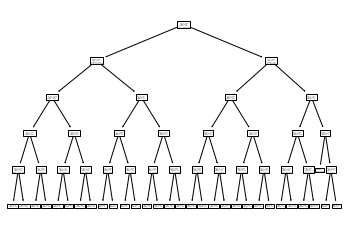

In [ ]:
from sklearn import tree
tree.plot_tree(clf)

# Exercício. Seleção de Atributos

Empregue a função `SelectKBest` do Scikit-learn para determinar os 3 atributos que carregam mais informação para a determinação da classe `y`.

**Dica**: Lembre-se de empregar os valores de entrada `X` já com o label encode e normalizados.



In [10]:
# import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2 # Teste estatístico para classificação
import numpy as np

# ==============================================================================
# EXERCÍCIO: SELEÇÃO DE ATRIBUTOS (SELECTKBEST)
# ==============================================================================

# OBSERVAÇÃO: Esta célula assume que X (normalizado e label encoded)
# e y_encoded (0 e 1) foram criados nas células anteriores.

# NOTA IMPORTANTE: O teste Chi-Quadrado (chi2) só aceita valores não negativos.
# Como o X foi normalizado (StandardScaler), ele contém valores negativos.
# Para usar o chi2, precisamos reescalonar X para valores positivos (e.g., Min-Max [0, 1])
# OU usar outro teste como f_classif.
# Para manter a simplicidade e a robustez contra a normalização Z-Score,
# usaremos f_classif, que é o teste F (ANOVA) para classificação.

from sklearn.feature_selection import f_classif

k = 3 # Número de atributos a serem selecionados

print(f"Iniciando Seleção dos {k} Melhores Atributos usando f_classif...")

# 1. Criar e configurar o seletor
# Usamos f_classif (Teste F) porque o X normalizado tem valores negativos
seletor = SelectKBest(score_func=f_classif, k=k)

# 2. Aplicar o seletor aos dados de TREINAMENTO (fit)
# Idealmente, o fit deve ser feito apenas nos dados de treino para evitar data leakage
seletor.fit(X_train, y_train)

# 3. Obter as pontuações e os atributos selecionados
pontuacoes = pd.Series(seletor.scores_, index=X_train.columns)
atributos_selecionados = pontuacoes.nlargest(k)

# 4. Exibir os resultados
print("\n### RESULTADOS SELECTKBEST (f_classif) ###")
print(f"Os {k} atributos mais informativos são:")
print("-" * 40)
print(atributos_selecionados)
print("-" * 40)

# Opcional: Criar os novos conjuntos de dados apenas com os atributos selecionados
# X_train_new = X_train[atributos_selecionados.index]
# X_test_new = X_test[atributos_selecionados.index]
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif



Iniciando Seleção dos 3 Melhores Atributos usando f_classif...

### RESULTADOS SELECTKBEST (f_classif) ###
Os 3 atributos mais informativos são:
----------------------------------------
duration    6079.939893
contact      707.028283
housing      591.747635
dtype: float64
----------------------------------------
